# Load data

In [14]:
# Imports
import numpy as np
import BLEanalysis.angleinference as AngleInference
np.set_printoptions(precision=2,suppress=True)
import matplotlib.pyplot as plt
from BLEanalysis.signals import Signals
from BLEanalysis.angleinference import AnglesUsePatternMeans, normalise_logs_to_ps
from BLEanalysis.angleinference import AnglesUsePeaks
from scipy.stats import circmean
import pandas as pd
import matplotlib as mpl

In [15]:
# Training data used for angle inference, consists of reading many packets over many rotations of the transmitter at a different
# location to that of the test data. This file was taken at Ponderosa Park, Sheffield, UK
trainingsigs = Signals("../bluetooth_experiments/no rf amp experiments/noamploc2long.log", ['d'], angleOffset = 38)
    
# Helper function to subsample randomly from a set of signal strengths
def randomSampleFromBurstDict(dict, n):
    samples = {}
    samples['transmitter_position'] = dict['transmitter_position']
    samples['rssis'] = []
    samples['angles'] = []
    samples['times'] = []
    # Randomly select unique indices
    
    #rand_indices = np.random.choice(len(dict['rssis']), size=n, replace=False)
    rand_indices = np.linspace(0, len(dict['rssis'])-1, n)
    rand_indices = [int(x) for x in rand_indices]
    
    # We rotate these indecies so we don't always hit near the peak for some particular n of samples
    rotationValue = np.random.randint(0,len(dict['rssis'])-1)
    rand_indices = [((x + rotationValue ) - (len(dict['rssis'])-1)) for x in rand_indices]
    
    #print(rotationValue)
    # Collect samples at those indices
    samples['rssis'] = np.array([dict['rssis'][i] for i in rand_indices])
    samples['angles'] = np.array([dict['angles'][i] for i in rand_indices])
    samples['times'] = np.array([dict['times'][i] for i in rand_indices])

    return samples

# Helper function to calculate error between two angles
def angularDistance(a1, a2):
    diff = abs(a1 - a2) % 360
    return np.abs(min(diff, 360 - diff))

Standardising angles and times (shifting by 38.00 degrees)


Standardising angles and times (shifting by 0.00 degrees)
Transmitter       Number of records
        c                 8315
Standardising angles and times (shifting by 38.00 degrees)
100000ms out of 733482ms added to table.
110000ms out of 733482ms added to table.
120000ms out of 733482ms added to table.
130000ms out of 733482ms added to table.
140000ms out of 733482ms added to table.
150000ms out of 733482ms added to table.
160000ms out of 733482ms added to table.
170000ms out of 733482ms added to table.
180000ms out of 733482ms added to table.
190000ms out of 733482ms added to table.
200000ms out of 733482ms added to table.
210000ms out of 733482ms added to table.
220000ms out of 733482ms added to table.
230000ms out of 733482ms added to table.
240000ms out of 733482ms added to table.
250000ms out of 733482ms added to table.
260000ms out of 733482ms added to table.
270000ms out of 733482ms added to table.
280000ms out of 733482ms added to table.
290000ms out of 733482ms added to tab

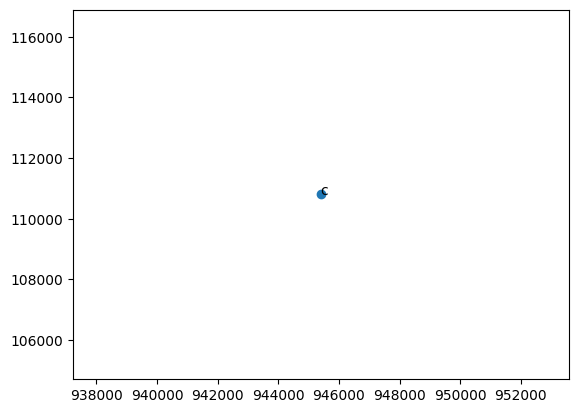

In [16]:
# Load in test data, measured at Common Lane Open Space, Sheffield, UK
testsigs = Signals("../bluetooth_experiments/March 26 2025 Field Trial/Range Trials/1.log",['c'],angleOffset= 0)
testsigs.configureTransmitter('c',0,0,1,1)
testsigs.noramliseTransmitterLocs()
testsigs.summarise(showNormalised = False)
# Build rejection sampling table
rejectionSampling = AngleInference.AnglesUseRejectionSampling(rejectionTableStep = 10)

Our data looks like this:

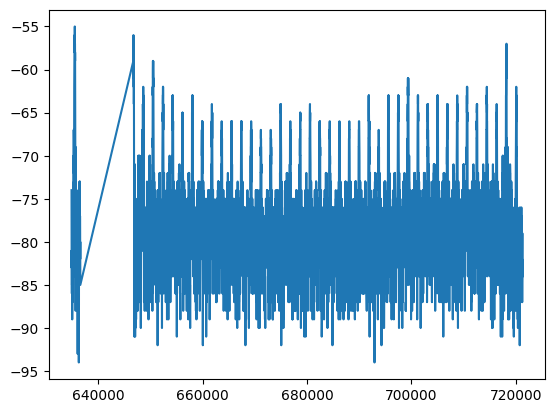

In [17]:
plt.plot([i[3] for i in testsigs.data],[i[0] for i in testsigs.data])
plt.show()

Cut off the first and last bursts as they were taken when we were setting up and turning off the reciever, therefore were subject to additional obstructions

In [18]:
testsigs.data = testsigs.data[250:len(testsigs.data)-40]

Since we can't exactly know what true angle the reciever was located at from the transmitter in the test data due to human error of where we placed the reciever (in this test, aimed to be at 0 degrees), we will instead use the average of the angles in the packets with peak RSSIs of every transmitter rotation that was meausred.

In [19]:
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
peaks = []
for b in burst:
    maxind = np.argmax(b['rssis'])
    peaks.append(b['angles'][maxind])

groundTruthAngle = 360 - np.rad2deg(circmean(peaks)) % 360
print("True angle = " + str(groundTruthAngle))

True angle = 356.9461548619557


# Inference Example

Choose a burst scan:

In [8]:
burstIndex = 20
nSamps = 2000

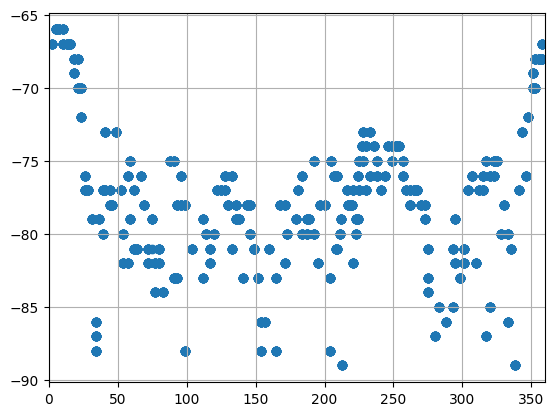

In [9]:
# THIS PLOT SHOWS PACKETS AS THEY ARE, NOT ADJUSTED FOR BEING COUNTERCLOCKWISE
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
currentBurst = randomSampleFromBurstDict(burst[burstIndex], nSamps)
plt.scatter(np.rad2deg(currentBurst['angles']), currentBurst['rssis'])
plt.xlim(0,360)
plt.grid()

Probability via pattern matching:

Standardising angles and times (shifting by 38.00 degrees)
Highest density at angle: 355
NLPD178.1395771355783


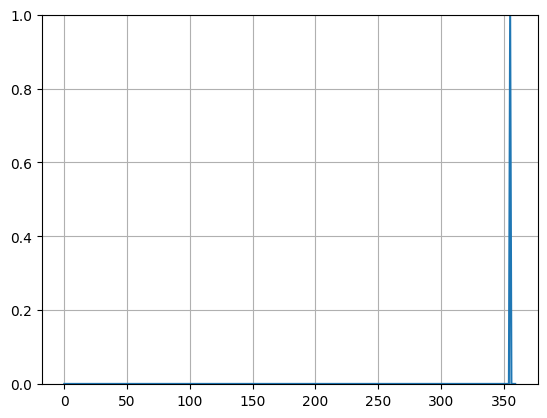

In [10]:
import scipy
angles = AnglesUsePatternMeans(noisevar=3**2)

logps,_,_,_ = angles.infer(currentBurst['rssis'],currentBurst['angles'])
#logps = np.log(np.exp(logps)+1e-1000)
ps = normalise_logs_to_ps(logps)
plt.plot(np.linspace(0,359,360),ps)
#print(np.max(logps),np.max(ps),np.sum(ps))
        
plt.ylim([-0.001,1]) #1.1*np.max(ps)])
plt.grid()
print("Highest density at angle: " + str(np.argmax(ps)))
print("NLPD" + str(-np.log(ps[groundTruthAngle.astype(int)])))

Smoothing and peak finding:

In [11]:
angles = AnglesUsePeaks(windowLength = 3 )
prediction = angles.infer(currentBurst['rssis'],currentBurst['angles'])
print(np.rad2deg(prediction))

355.0


Rejection sampling:

In [12]:
# TODO : Make result clockwise in the graph
results = rejectionSampling.inferFromBurst(currentBurst,filter = False, plot = True, filterMean = 0, filterStd = 0.5 )
print("Circular average of sampled angles: " + str(np.rad2deg(circmean([x[1] for x in results]))))
#print([np.rad2deg(x[1]) for x in results])

NameError: name 'rejectionSampling' is not defined

# Tabulated comparison

In [30]:
# Load data and define tests to perform
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
nSamps = [3,4,5,6,7,8,9,10,15,20,25,30,40,50,100]
nTests = 100
rejectionSampResults = []
peakFindingResults= []
fullProbDistResults = []
anglesPattern = AnglesUsePatternMeans(noisevar=3**2)
anglesPeak = AnglesUsePeaks(windowLength = 3)

# For each specified number of samples
for x, n in enumerate(nSamps):
    current_rejectionSampResults = []
    current_peakFindingResults= []
    current_fullProbDistResults = []
    # Repeat test nTests times
    for i in range(nTests):
        # Select burst and randomly sample from it
        burstIndex = np.random.randint(0, len(burst)-1)
        currentBurst = randomSampleFromBurstDict(burst[burstIndex], n)

        # Get prediction from probability distribution
        logps,_,_,_ = anglesPattern.infer(currentBurst['rssis'],currentBurst['angles'])
        ps = normalise_logs_to_ps(logps)
        current_fullProbDistResults.append(angularDistance(groundTruthAngle, np.argmax(ps)))

        # Get prediction from peak finding heuristic
        prediction = anglesPeak.infer(currentBurst['rssis'],currentBurst['angles'])
        current_peakFindingResults.append(angularDistance(groundTruthAngle, np.rad2deg(prediction)))

        # Get prediction from rejection sampling 
        predictions = rejectionSampling.inferFromBurst(currentBurst,filter = False, plot = False, sampleInterval = 10,
                                              filterMean = 0, filterStd = 1)
        prediction = np.rad2deg(circmean(predictions))
        #if np.isnan(prediction) == False:
        current_rejectionSampResults.append(angularDistance(groundTruthAngle,prediction))
    
    rejectionSampResults.append(current_rejectionSampResults)
    peakFindingResults.append(current_peakFindingResults)
    fullProbDistResults.append(current_fullProbDistResults)

Standardising angles and times (shifting by 38.00 degrees)


/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:215: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


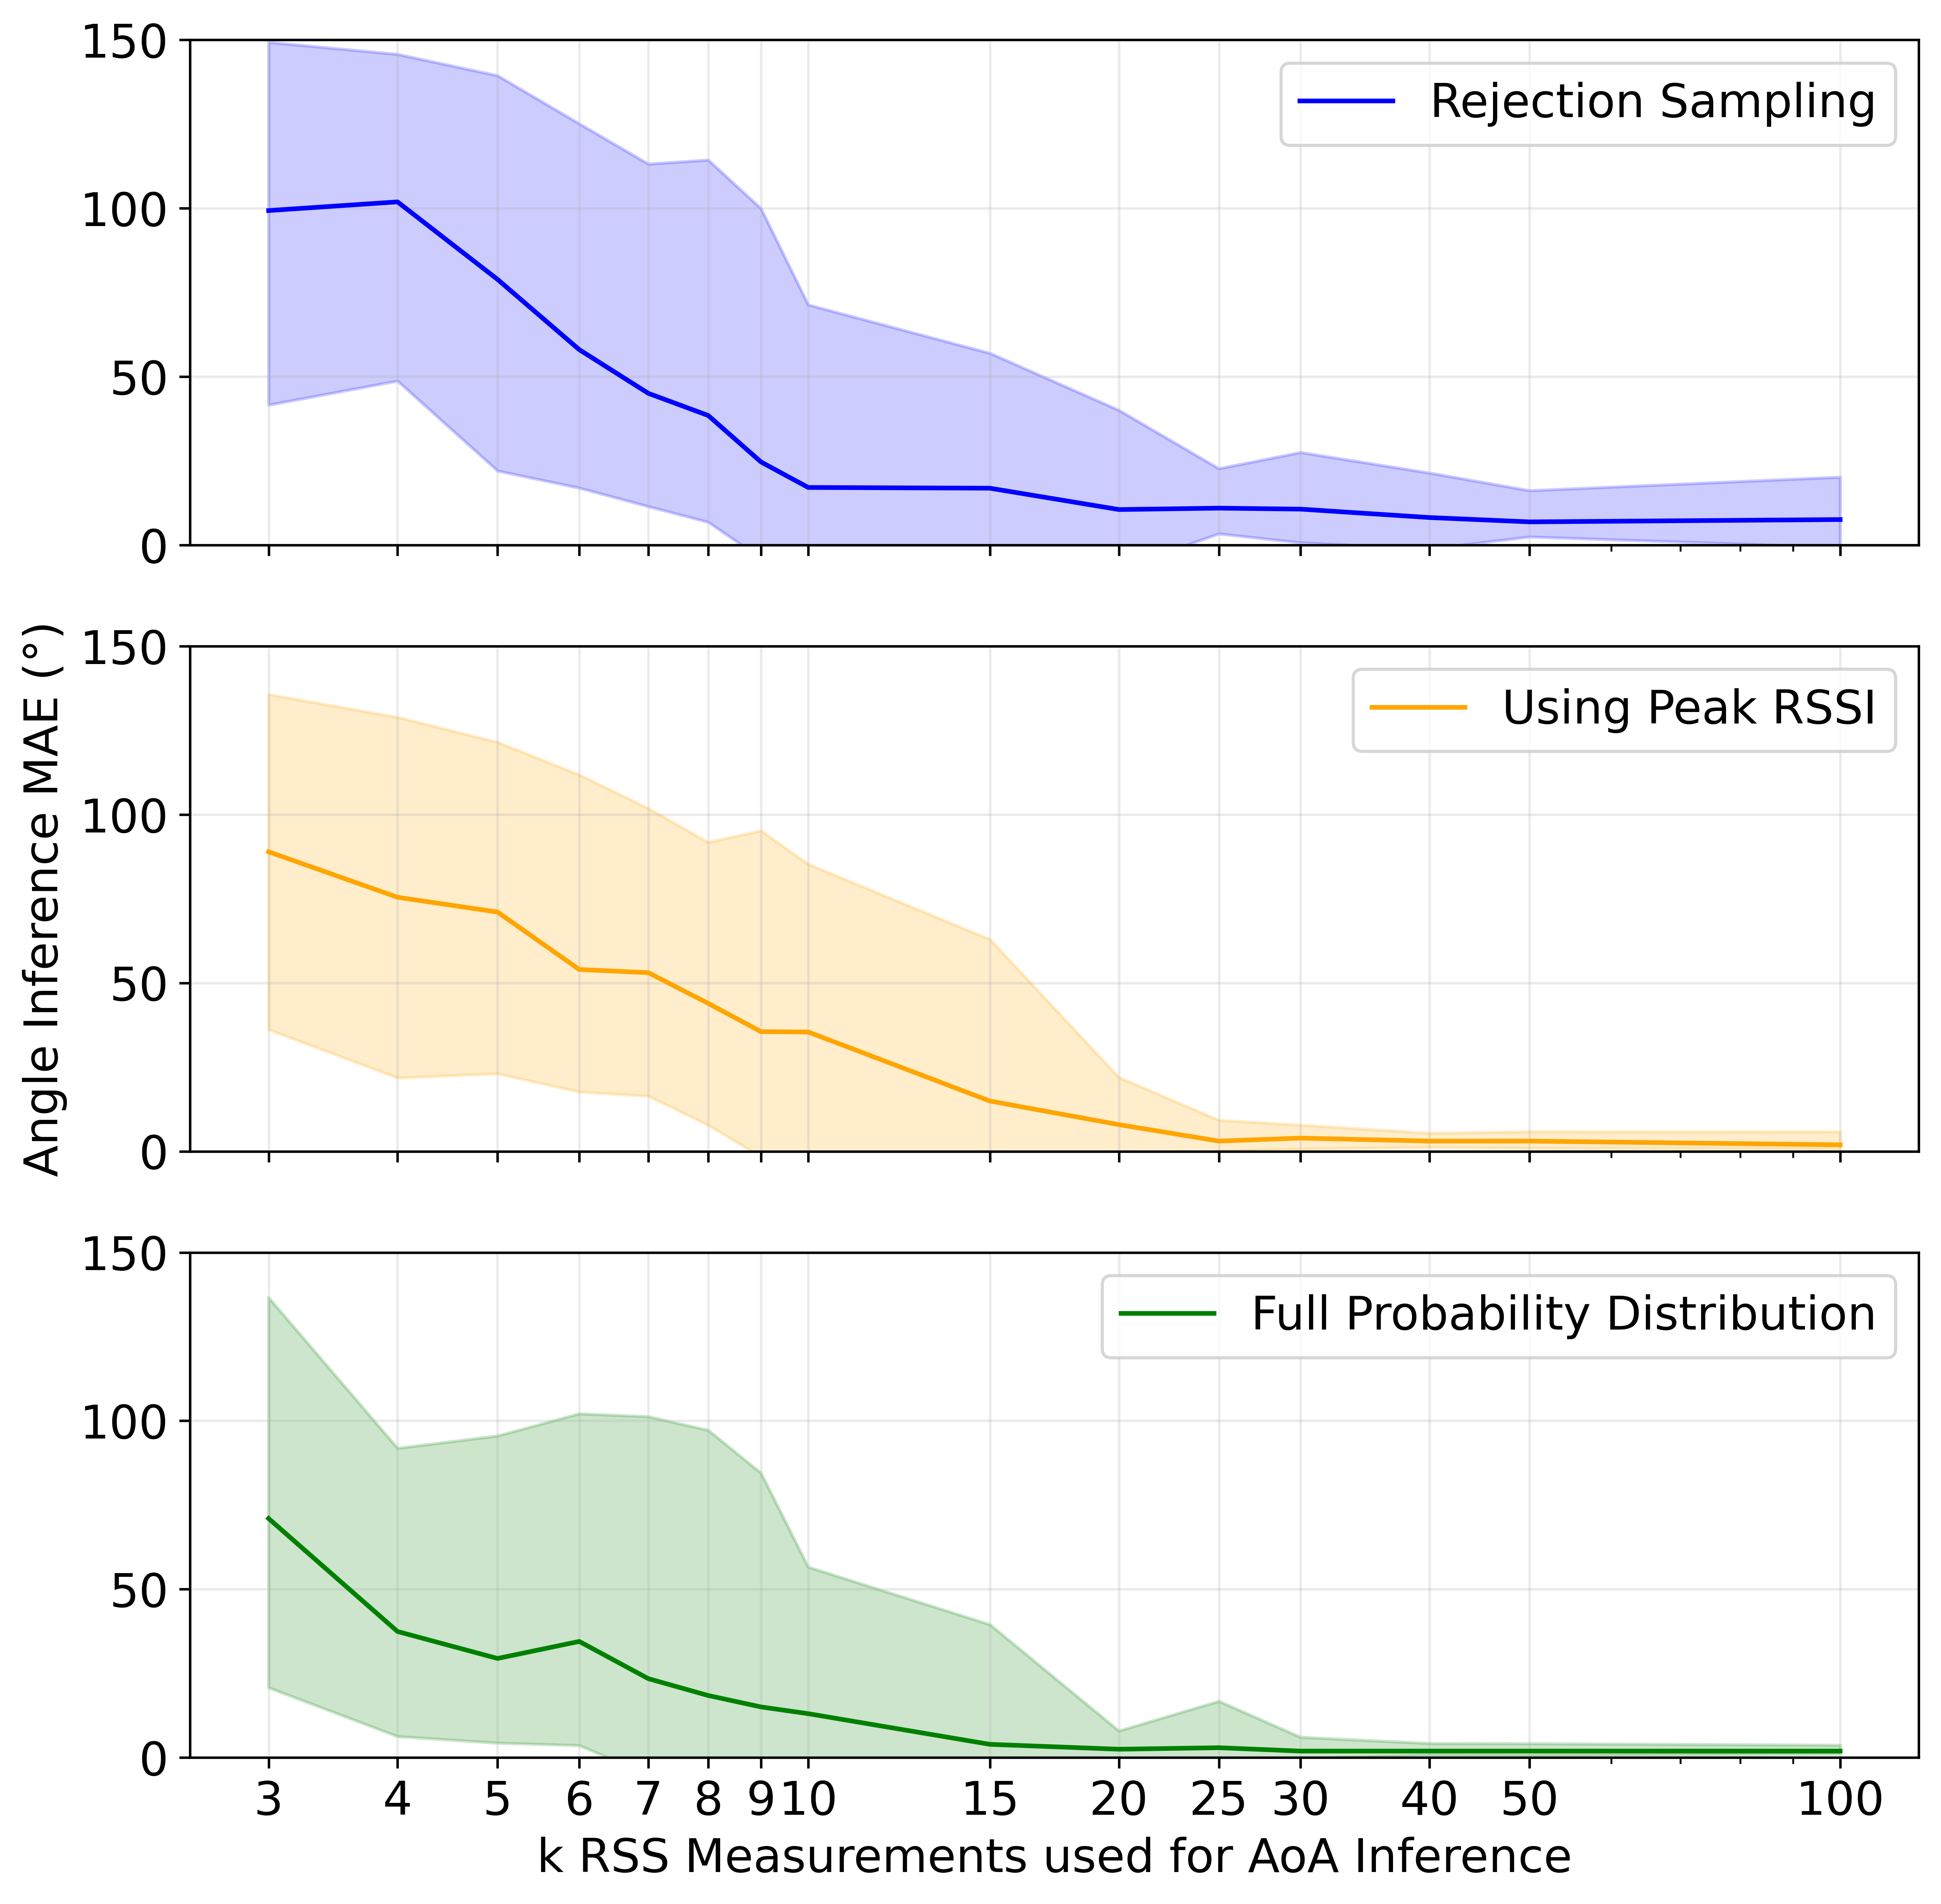

In [31]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 15}

mpl.rc('font', **font)
fig, ax1 = plt.subplots(3,1,figsize=(10,10), sharex=True, sharey=True,dpi=600)
ax1[0].plot(nSamps,[np.median(x) for x in rejectionSampResults], label = "Rejection Sampling", color="blue")
ax1[0].fill_between(
    nSamps,
    [m + s for m, s in zip([np.mean(x) for x in rejectionSampResults], [np.std(x) for x in rejectionSampResults])],
    [m - s for m, s in zip([np.mean(x) for x in rejectionSampResults], [np.std(x) for x in rejectionSampResults])],
    color="blue",
    alpha=0.2,
)
ax1[1].plot(nSamps,[np.median(x) for x in peakFindingResults], label = "Using Peak RSSI",color="orange")
ax1[1].fill_between(
    nSamps,
    [m + s for m, s in zip([np.mean(x) for x in peakFindingResults], [np.std(x) for x in peakFindingResults])],
    [m - s for m, s in zip([np.mean(x) for x in peakFindingResults], [np.std(x) for x in peakFindingResults])],
    color="orange",
    alpha=0.2,
)
ax1[2].plot(nSamps,[np.median(x) for x in fullProbDistResults], label = "Full Probability Distribution",color="green")
ax1[2].fill_between(
    nSamps,
    [m + s for m, s in zip([np.mean(x) for x in fullProbDistResults], [np.std(x) for x in fullProbDistResults])],
    [m - s for m, s in zip([np.mean(x) for x in fullProbDistResults], [np.std(x) for x in fullProbDistResults])],
    color="green",
    alpha=0.2,
)
ax1[1].set_ylabel("Angle Inference MAE (°)")
ax1[0].legend()
ax1[1].legend()
ax1[2].legend()
plt.xlabel("k RSS Measurements used for AoA Inference")
plt.ylim(0,150)
plt.xscale("log")
plt.xticks(nSamps, [str(t) for t in nSamps])
ax1[0].grid(alpha=0.25)
ax1[1].grid(alpha=0.25)
ax1[2].grid(alpha=0.25)

# Confidence of Angle Prediction vs Accuracy

Here I select a burst scan, vary the number k RSSI measurements within, and for each k I plot the MAE of angle prediction (argmax of the pd) against the confidence of the inferred proability density. This shows if the confidence of the pd gives any meaningful information about the true angle.

In [43]:
import scipy
burstIndex = 10
k = [3,5,10,15,20,25,30,40,50,75,100,200]
angles = AnglesUsePatternMeans(noisevar=20**2)
accuracies = []
variances = []
nTests = 1000

for samps in k:
    currentvar = []
    currentacc = []
    for x in range(nTests):
        burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
        currentBurst = randomSampleFromBurstDict(burst[burstIndex], samps)

        logps,_,_,_ = angles.infer(currentBurst['rssis'],currentBurst['angles'])
        ps = normalise_logs_to_ps(logps)
        # NLPD
        currentacc.append(-np.log(ps[groundTruthAngle.astype(int)])) #angularDistance(groundTruthAngle, np.argmax(ps)))
        # Entropy
        currentvar.append(scipy.stats.entropy(ps))
        #a = np.linspace(0,np.pi*2,360)
        #currentvar.append(np.sum(np.cos(a)*
    accuracies.append(np.mean(currentacc))
    variances.append(np.mean(currentvar))

Standardising angles and times (shifting by 38.00 degrees)


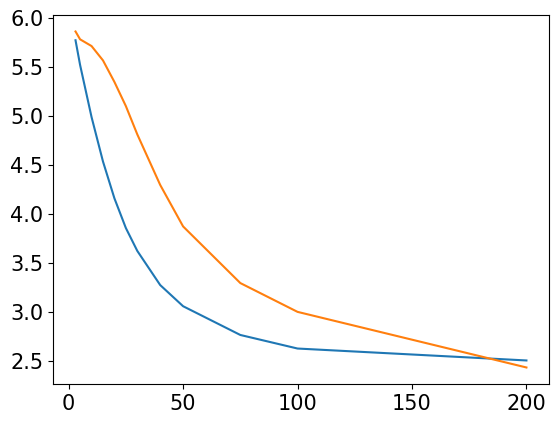

In [44]:
plt.plot(k, accuracies)
plt.plot(k, variances)

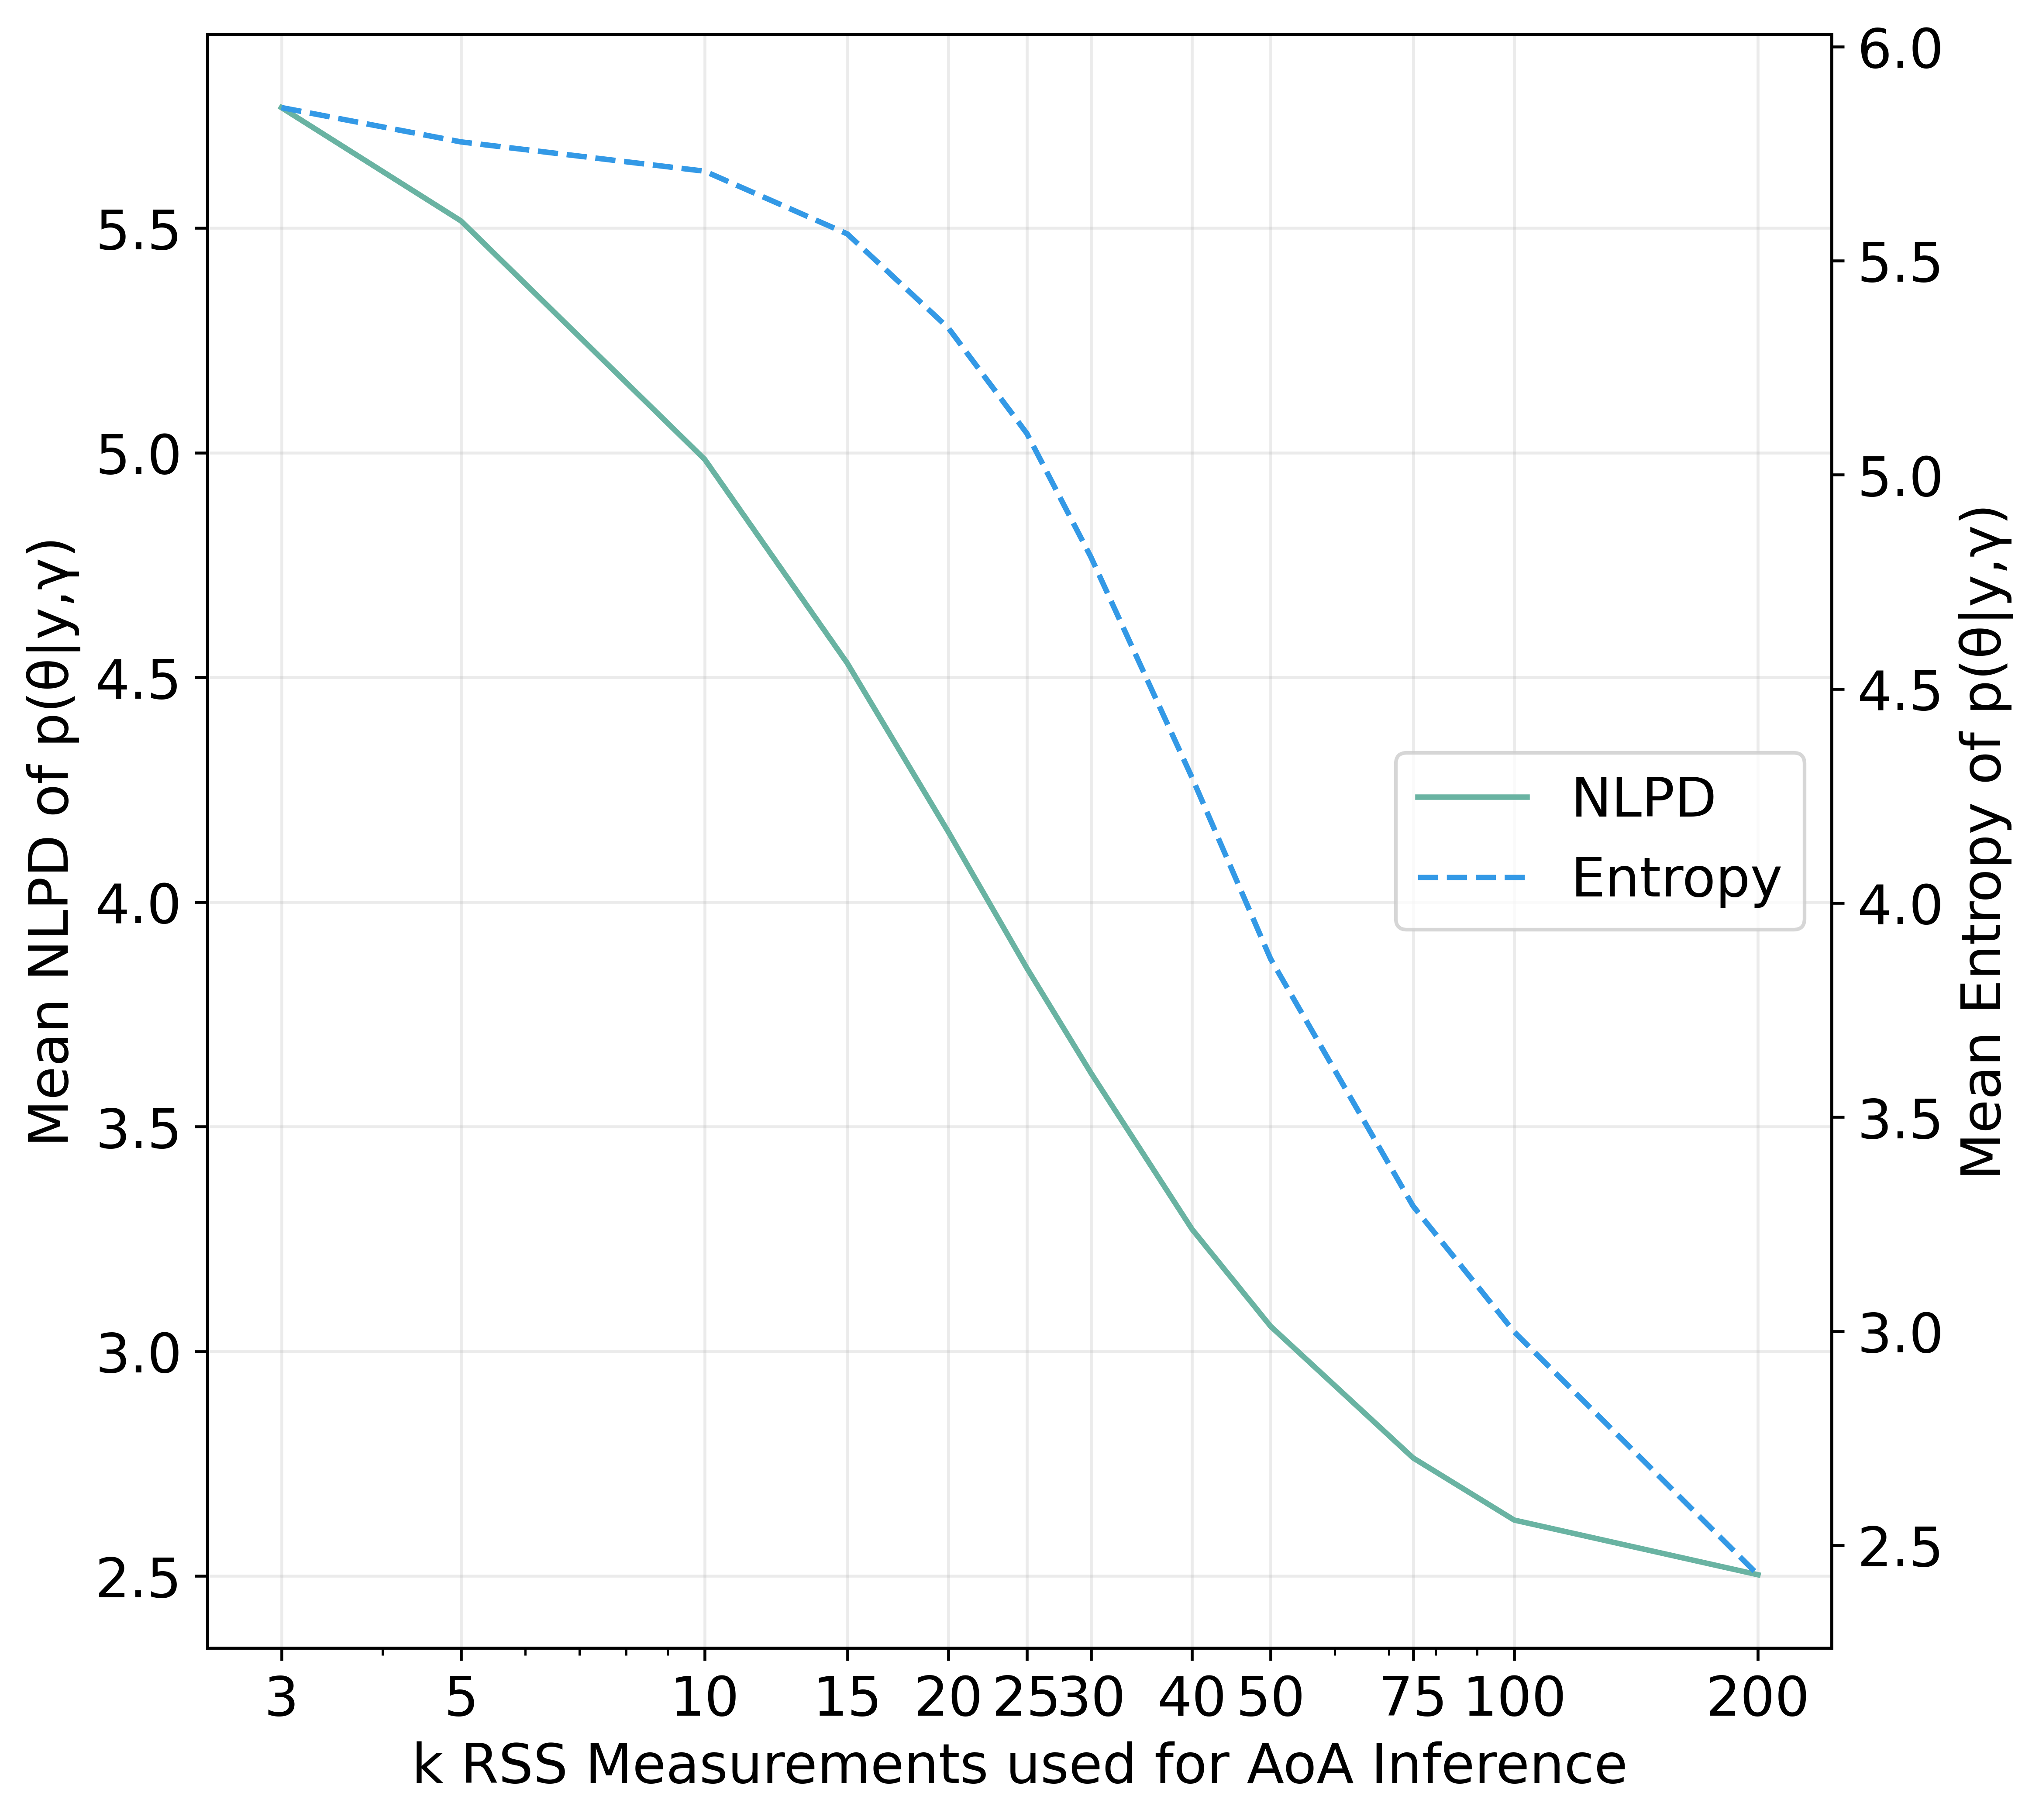

In [48]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 15}

mpl.rc('font', **font)
COLOUR_ANGLE = "#69b3a2"
COLOUR_VAR = "#3399e6"

fig, ax1 = plt.subplots(figsize=(8, 8), dpi = 600)
ax2 = ax1.twinx()

ax1.plot(k,accuracies, color=COLOUR_ANGLE, label = "NLPD")
#ax1.fill_between([(PACKET_ALLOWANCE/x) for x in k], [np.mean(x[0]) + np.std(x[0])*1.96 for x in results], [np.mean(x[0]) - np.std(x[0])*1.96 for x in results], color=COLOUR_PATH,alpha=0.2,label = "Path Reconstruction")

ax2.plot(k, variances, '--', color=COLOUR_VAR,label = "Entropy")

ax1.set_xlabel("k RSS Measurements used for AoA Inference")

ax1.set_ylabel("Mean NLPD of p(θ|y,γ)")
ax2.set_ylabel("Mean Entropy of p(θ|y,γ)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.xscale("log")
plt.xticks(k, [str(t) for t in k], fontsize=5)
ax1.grid(alpha=0.25)
plt.savefig("nlpd.png")

